# US Visa Prediction Project
**Life cycle of Machine learning Project**

* Understanding the Problem Statement
* Data Collection
* Exploratory data analysis
* Data Cleaning
* Data Pre-Processing
* Model Training 
* Choose best model

### About
The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. 
The act also protects US workers against adverse impacts on working place and maintain requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

## 1) Problem statement.

* OFLC gives job certification applications for employers seeking to bring foreign workers into the United States and grants certifications. 
* As In last year the count of employees were huge so OFLC needs Machine learning models to shortlist visa applicants based on their previous data.

**In this project we are going to use the data given to build a Classification model:**

* This model is to check if Visa get approved or not based on the given dataset.
* This can be used to Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the certain criteria which influences the decision.

## 2) Data Collection.
* The Dataset is part of Office of Foreign Labor Certification (OFLC)
* The data consists of 25480 Rows and 12 Columns

https://www.kaggle.com/datasets/moro23/easyvisa-dataset

### 2.1 Import Data and Required Packages
**Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

warnings.filterwarnings("ignore")

%matplotlib inline

In [3]:
#Import the CSV Data as Pandas DataFrame**
df= pd.read_csv("C:/Users/shaya/Desktop/labmentix/mMLOPs-Production-Ready-Machine-Learning-Project/notebook/Visadataset.csv")
                

In [4]:
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [5]:
#shape of data
df.shape

(25480, 12)

In [6]:
#summary of dataset
df.describe()

,no_of_employees,yr_of_estab,prevailing_wage
count,25480.000000,25480.000000,25480.000000
mean,5667.043210,1979.409929,74455.814592
std,22877.928848,42.366929,52815.942327
min,-26.000000,1800.000000,2.136700
25%,1022.000000,1976.000000,34015.480000
50%,2109.000000,1997.000000,70308.210000
75%,3504.000000,2005.000000,107735.512500
max,602069.000000,2016.000000,319210.270000


In [7]:
#check dtypes and null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


In [8]:
#3. EXPLORING DATA
# define numerical & categorical columns
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

# print columns
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 3 numerical features : ['no_of_employees', 'yr_of_estab', 'prevailing_wage']

We have 9 categorical features : ['case_id', 'continent', 'education_of_employee', 'has_job_experience', 'requires_job_training', 'region_of_employment', 'unit_of_wage', 'full_time_position', 'case_status']


In [9]:
type(categorical_features)

list

In [10]:
print(f"we have{len(numeric_features)} numerical features : {numeric_features}")

we have3 numerical features : ['no_of_employees', 'yr_of_estab', 'prevailing_wage']


In [11]:
for col in categorical_features:
    print(df[col].value_counts(normalize=True) * 100)

case_id
EZYV01       0.003925
EZYV02       0.003925
EZYV03       0.003925
EZYV04       0.003925
EZYV05       0.003925
               ...   
EZYV25476    0.003925
EZYV25477    0.003925
EZYV25478    0.003925
EZYV25479    0.003925
EZYV25480    0.003925
Name: proportion, Length: 25480, dtype: float64
continent
Asia             66.173469
Europe           14.646782
North America    12.919937
South America     3.343799
Africa            2.162480
Oceania           0.753532
Name: proportion, dtype: float64
education_of_employee
Bachelor's     40.164835
Master's       37.810047
High School    13.422292
Doctorate       8.602826
Name: proportion, dtype: float64
has_job_experience
Y    58.092622
N    41.907378
Name: proportion, dtype: float64
requires_job_training
N    88.402669
Y    11.597331
Name: proportion, dtype: float64
region_of_employment
Northeast    28.237834
South        27.539246
West         25.847724
Midwest      16.903454
Island        1.471743
Name: proportion, dtype: float64
unit_o

**Insights**
 - `case_id` have unique vlaues for each column which can be dropped as it it of no importance
 - `continent` column is highly biased towards asia. hence we can combine other categories to form a single category.
 - `unit_of_wage` seems to be an important column as most of them are yearly contracts.

## Univariate Analysis
* The term univariate analysis refers to the analysis of one variable prefix “uni” means “one.” The purpose of univariate analysis is to understand the distribution of values for a single variable.

Other Type of Analysis are
* **Bivariate Analysis:** The analysis of two variables.
* **Multivariate Analysis:** The analysis of two or more variables.

plotting numeric columns

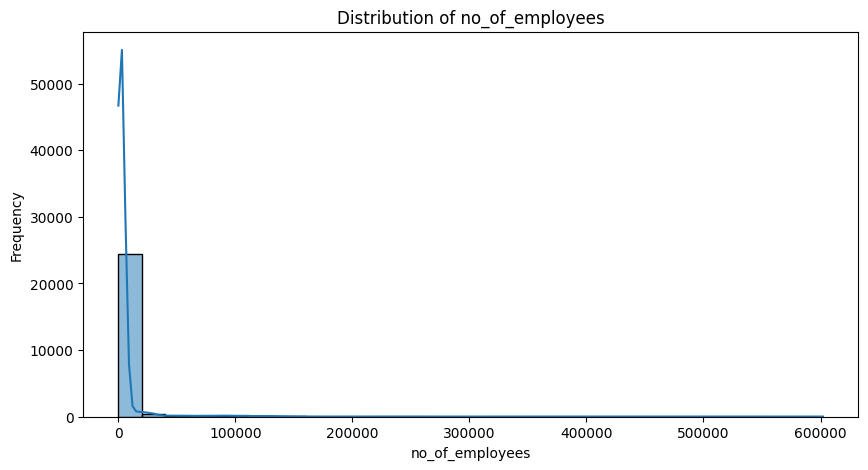

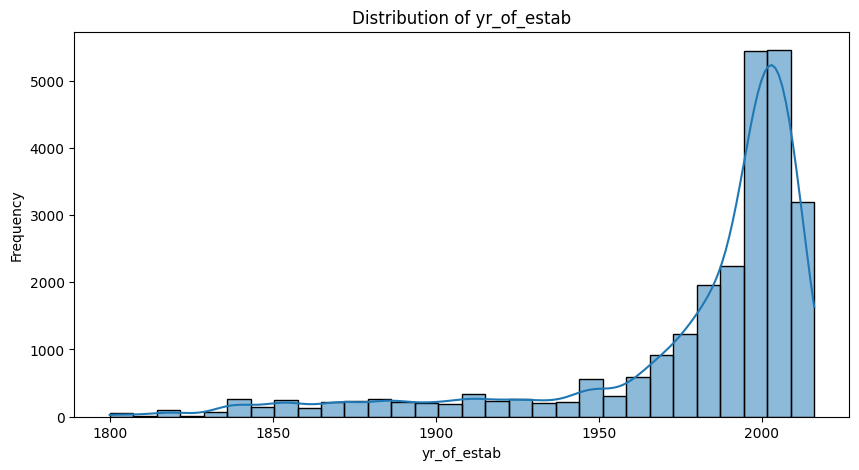

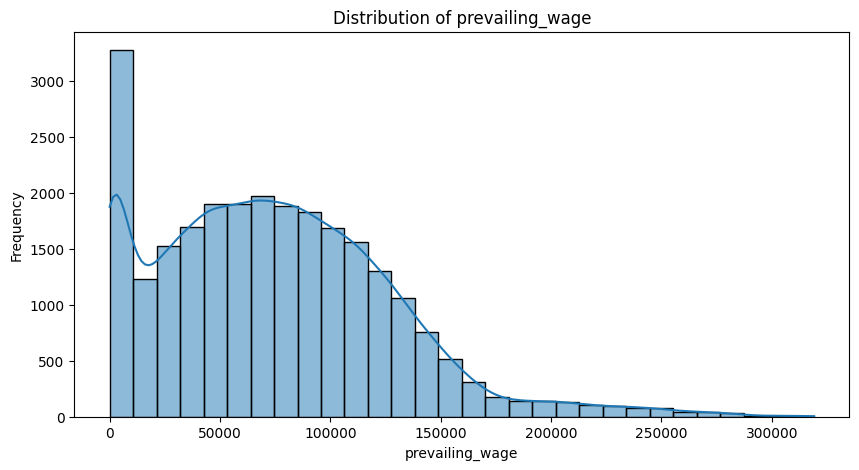

In [12]:
for i in numeric_features:
    plt.figure(figsize=(10, 5))
    sns.histplot(df[i], kde=True, bins=30)
    plt.title(f'Distribution of {i}')
    plt.xlabel(i)
    plt.ylabel('Frequency')
    plt.show()


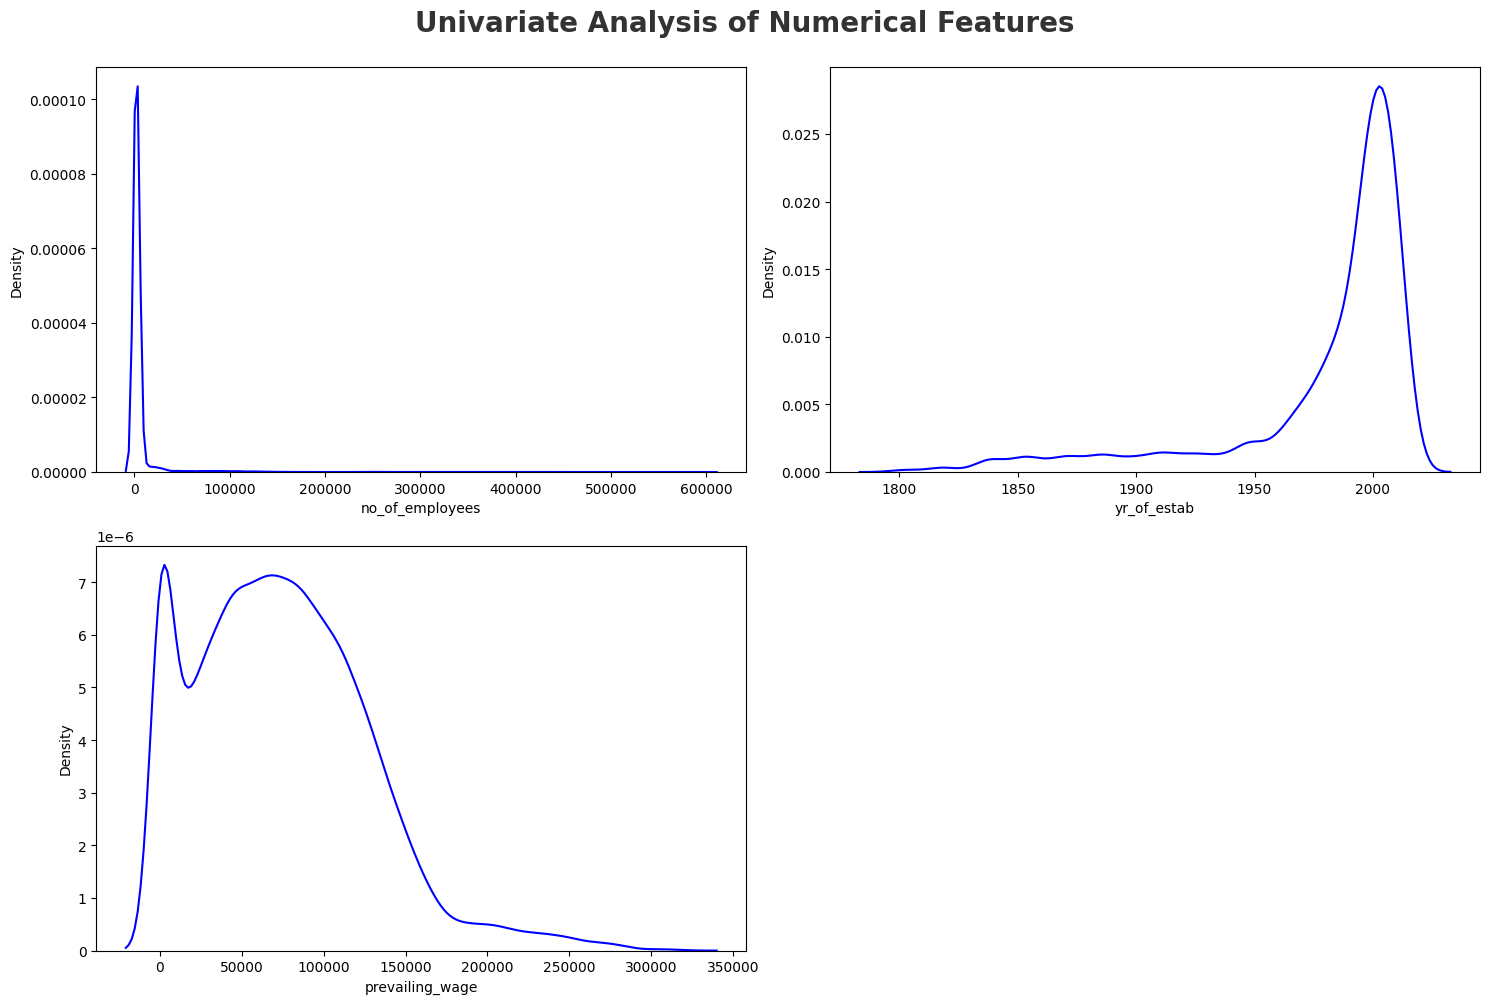

In [13]:
plt.figure(figsize=(15, 10))
plt.suptitle('Univariate Analysis of Numerical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

for i in range(0, len(numeric_features)):
    plt.subplot(2, 2, i+1)
    sns.kdeplot(x=df[numeric_features[i]], color='blue')
    plt.xlabel(numeric_features[i])
    plt.tight_layout()
    

**Insights**
 - `no_of_employees` column looks more skewed but it may be because of outlies.
 - `yr_of_estab` is a discrete feature.
 - `privailing-wage` is a right-skewed distribution.

plotting categorial features

In [14]:
categorical_features

['case_id',
 'continent',
 'education_of_employee',
 'has_job_experience',
 'requires_job_training',
 'region_of_employment',
 'unit_of_wage',
 'full_time_position',
 'case_status']

In [15]:
# categorical columns
categorical_features.remove('case_id')


In [16]:
categorical_features

['continent',
 'education_of_employee',
 'has_job_experience',
 'requires_job_training',
 'region_of_employment',
 'unit_of_wage',
 'full_time_position',
 'case_status']

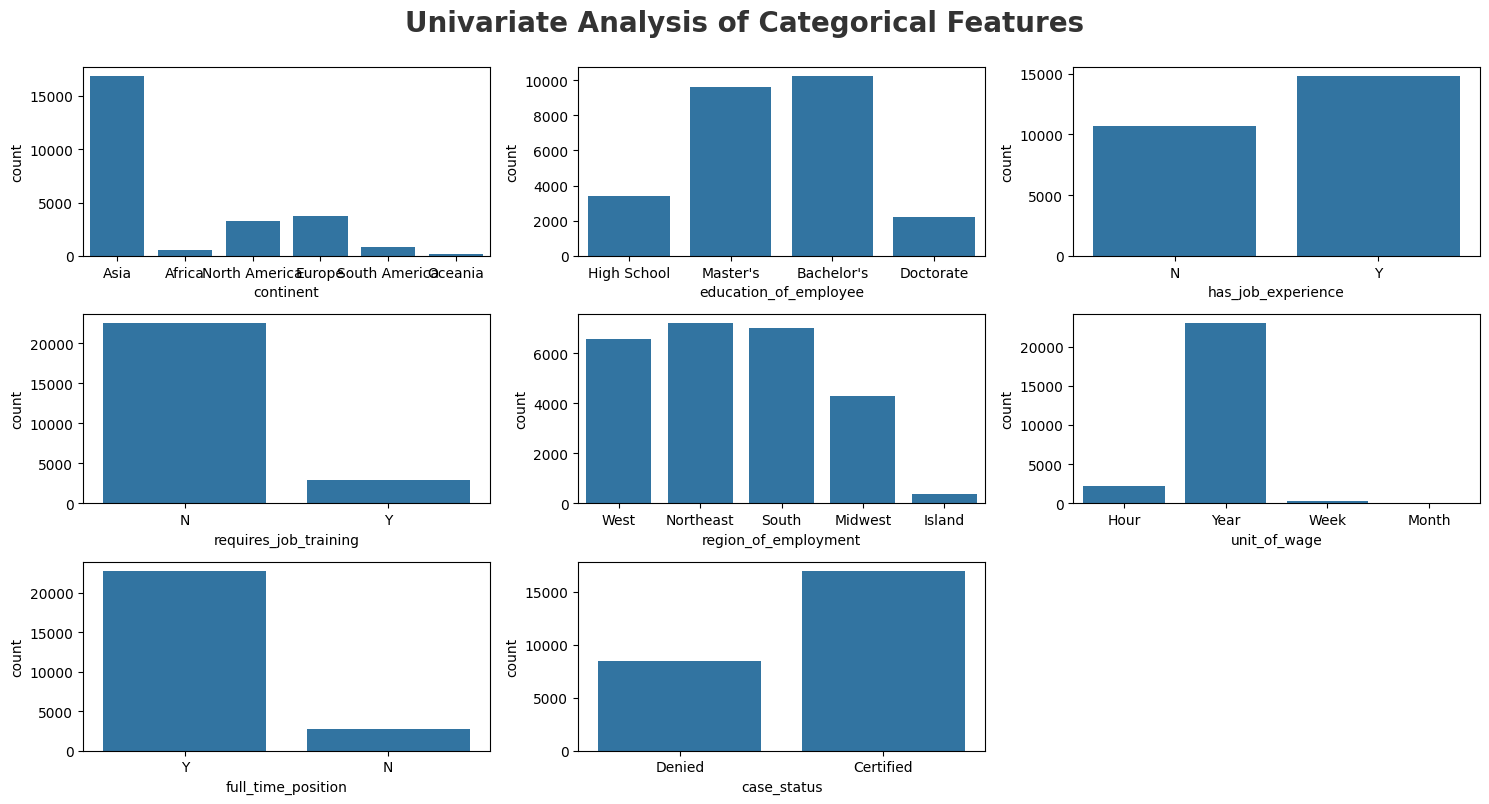

In [17]:
plt.figure(figsize=(15, 8))
plt.suptitle('Univariate Analysis of Categorical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

for i in range(0, len(categorical_features)):
    plt.subplot(3, 3, i+1)
    sns.countplot(x=df[categorical_features[i]])
    plt.xlabel(categorical_features[i])
    plt.tight_layout()

**Insights**
 - `requires_job_training`, `unit_of_wage`, `full_time_position` and `continents` coulmns have signle category dominating.
 - In rest of the columns are balanced.

* Multivariate analysis is the analysis of more than one variable.

In [18]:
discrete_features=[feature for feature in numeric_features if len(df[feature].unique())<=25]

continuous_features=[feature for feature in numeric_features if len(df[feature].unique()) > 25]

In [19]:
print(f"we have {len(discrete_features)} discrete features : {discrete_features}")
print(f"we have {len(continuous_features)} continuous features : {continuous_features}")

we have 0 discrete features : []
we have 3 continuous features : ['no_of_employees', 'yr_of_estab', 'prevailing_wage']


multicollinearity of nemerical features

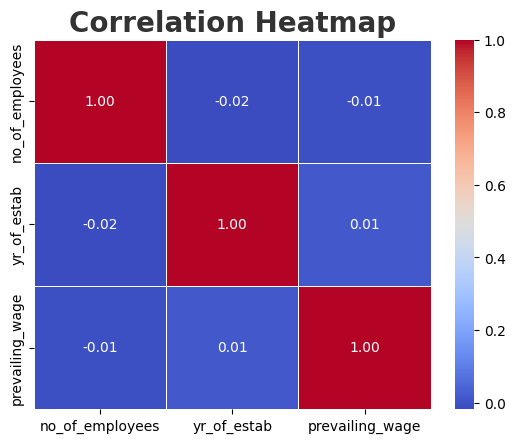

In [20]:
cor = df.corr(numeric_only=True)  # <-- no .all
sns.heatmap(cor, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=20, fontweight='bold', alpha=0.8)
plt.show()

In [21]:
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


### Check Multicollinearity for Categorical features
* **A chi-squared test (also chi-square or χ2 test) is a statistical hypothesis test that is valid to perform when the test statistic is chi-squared distributed under the null hypothesis, specifically Pearson's chi-squared test**

* **A chi-square statistic is one way to show a relationship between two categorical variables.**

* **Here we test correlation of Categorical columns with Target column i.e case_status**

Null Hypothesis ($ H_0 $): The Feature is independent of target column (No-Correlation)

Alternative Hypothesis ($ H_1 $): The Feature and Target column are not independent (Correalted)

In [22]:
from scipy.stats import chi2_contingency
chi2_test = []
for feature in categorical_features:
    if chi2_contingency(pd.crosstab(df['case_status'], df[feature]))[1] < 0.05:
        chi2_test.append('Reject Null Hypothesis')
    else:
        chi2_test.append('Fail to Reject Null Hypothesis')
result = pd.DataFrame(data=[categorical_features, chi2_test]).T
result.columns = ['Column', 'Hypothesis Result']
result

,Column,Hypothesis Result
0,continent,Reject Null Hypothesis
1,education_of_employee,Reject Null Hypothesis
2,has_job_experience,Reject Null Hypothesis
3,requires_job_training,Fail to Reject Null Hypothesis
4,region_of_employment,Reject Null Hypothesis
5,unit_of_wage,Reject Null Hypothesis
6,full_time_position,Reject Null Hypothesis
7,case_status,Reject Null Hypothesis


In [23]:
from scipy.stats import chi2_contingency
import pandas as pd

chi2_results = []  # store all results

for feature in categorical_features:
    chi2_statistic, p_value, dof, expected_freq = chi2_contingency(pd.crosstab(df['case_status'], df[feature]))
    
    # hypothesis result based on p-value
    hypothesis_result = 'Reject Null Hypothesis' if p_value < 0.05 else 'Fail to Reject Null Hypothesis'
    
    # store everything in a list
    chi2_results.append([feature, chi2_statistic, p_value, dof, expected_freq, hypothesis_result])

# create DataFrame
result = pd.DataFrame(chi2_results, columns=['Column', 'Chi2 Statistic', 'P-Value', 'DOF', 'Expected Freq', 'Hypothesis Result'])
result

,Column,Chi2 Statistic,P-Value,DOF,Expected Freq,Hypothesis Result
0,continent,351.380408,8.828798e-74,5,"[[368.0109105180534, 11261.401020408162, 2492....",Reject Null Hypothesis
1,education_of_employee,2772.207275,0.000000e+00,3,"[[6835.251648351648, 1464.028885400314, 2284.2...",Reject Null Hypothesis
2,has_job_experience,940.058096,1.922560e-206,1,"[[7131.797645211931, 9886.202354788069], [3546...",Reject Null Hypothesis
3,requires_job_training,1.752484,1.855647e-01,1,"[[15044.36616954474, 1973.633830455259], [7480...",Fail to Reject Null Hypothesis
4,region_of_employment,298.450836,2.338664e-63,4,"[[250.4611459968603, 2876.629748822606, 4805.5...",Reject Null Hypothesis
5,unit_of_wage,1108.507062,5.193385e-240,3,"[[1440.6525117739404, 59.44277864992151, 181.6...",Reject Null Hypothesis
6,full_time_position,4.029932,4.469975e-02,1,"[[1807.9955259026688, 15210.004474097332], [89...",Reject Null Hypothesis
7,case_status,25475.491853,0.000000e+00,1,"[[11366.260753532182, 5651.739246467818], [565...",Reject Null Hypothesis


In [24]:
#null value
df.isnull().sum()

case_id                  0
continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
yr_of_estab              0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
case_status              0
dtype: int64

In [25]:
continues_features=[feature for feature in numeric_features if len(df[feature].unique())>=10]
print('Num of continues features :',continues_features)

Num of continues features : ['no_of_employees', 'yr_of_estab', 'prevailing_wage']


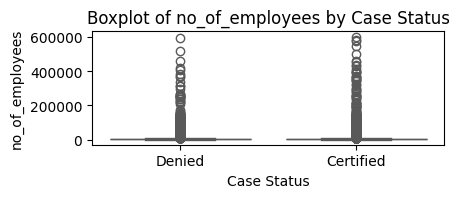

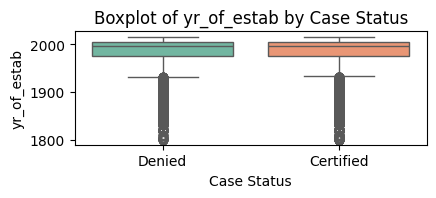

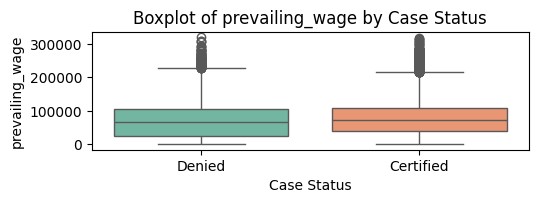

In [26]:

for i in range(len(continues_features)):
    plt.figure(figsize=(10, 5))
    plt.subplot(3,2,i+1)  # 3 rows, 2 columns, ith plot
    sns.boxplot(x='case_status', y=continues_features[i], data=df, palette='Set2')
   
    plt.xlabel('Case Status')
    plt.ylabel(continues_features[i])
    plt.title(f'Boxplot of {continues_features[i]} by Case Status')

plt.tight_layout()
plt.show()

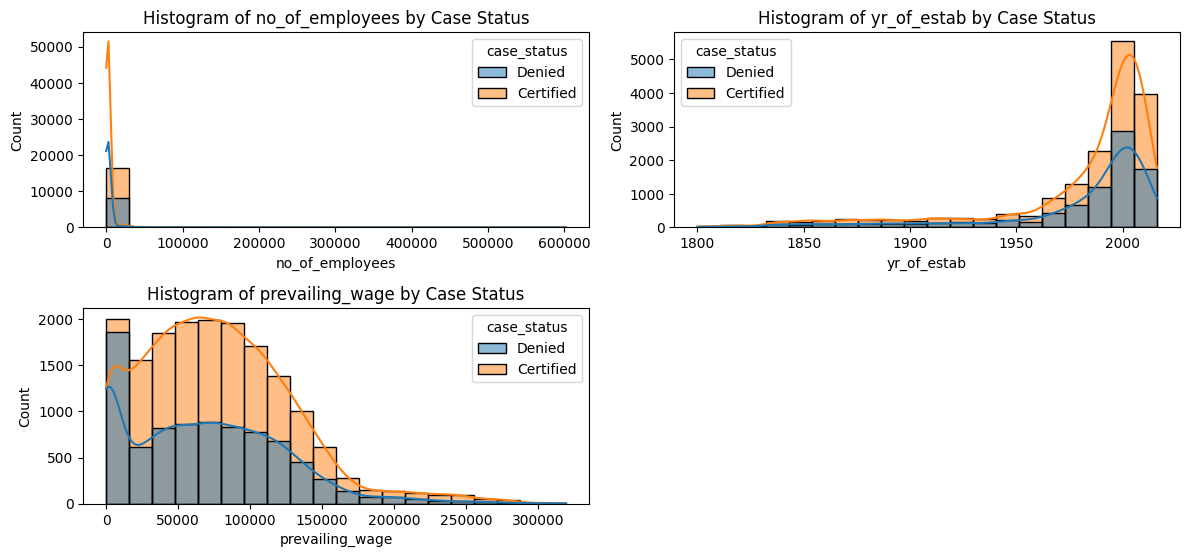

In [27]:


plt.figure(figsize=(12, 8))

for i in range(len(continues_features)):
    plt.subplot(3, 2, i+1)  # 3 rows, 2 columns
    sns.histplot(data=df, x=continues_features[i], hue='case_status', bins=20, kde=True)
    plt.xlabel(continues_features[i])
    plt.ylabel('Count')
    plt.title(f'Histogram of {continues_features[i]} by Case Status')

plt.tight_layout()
plt.show()

* **No of Employees has many outliers which can be Handled in Feature Engineering and `no_of_employees` is Right Skewed.**
* **`yr_of_estab` is left skewed and some outliers below the lower bound of Box plot.**
* **`prevailing_wage` is right skewed with outliers above upper bound of box plot.**
* **There are No missing values in the dataset.**
* **The `case_id` column can be deleted because each row has unique values.**
* **The `case_status` column is the target to predict.**
* **In the Categorical column, features can be made Binary numerical in feature Encoding**

4)visualise target

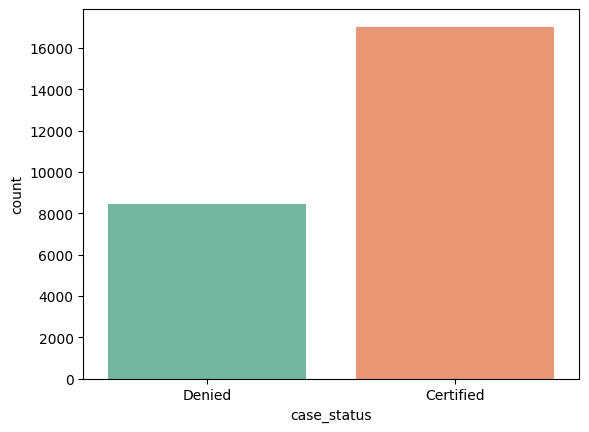

In [28]:
sns.countplot(x='case_status', data=df, palette='Set2')
plt.show()

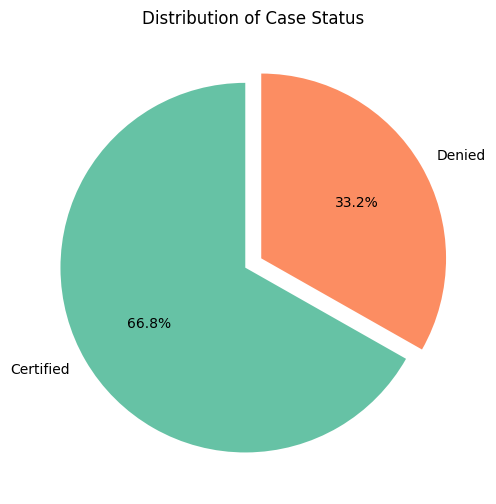

In [29]:
counts = df['case_status'].value_counts()
plt.figure(figsize=(6, 6))
df['case_status'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    explode=[0.05]* len(counts), 
    colors=sns.color_palette('Set2')
)
plt.title('Distribution of Case Status')
plt.ylabel('')
plt.show()

* From the chart it is seen that the Target Variable is Imbalanced
**What is imbalanced data?**

Imbalanced data are types of data where the target class has an uneven distribution of observations, i.e Here Denied value has more count than the Certified value of the dataset.

### 4.2 Does applicant Continent has any impact on Visa status ?

In [36]:
df.groupby('continent')['case_status'].value_counts(normalize=True).to_frame()*100

proportion
continent     case_status            
Africa        Certified     72.050817
              Denied        27.949183
Asia          Certified     65.310480
              Denied        34.689520
Europe        Certified     79.233655
              Denied        20.766345
North America Certified     61.877278
              Denied        38.122722
Oceania       Certified     63.541667
              Denied        36.458333
South America Certified     57.863850
              Denied        42.136150

In [37]:
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [39]:
df.groupby('education_of_employee')['case_status'].value_counts(normalize=True).to_frame()*100

proportion
education_of_employee case_status            
Bachelor's            Certified     62.214188
                      Denied        37.785812
Doctorate             Certified     87.226277
                      Denied        12.773723
High School           Denied        65.964912
                      Certified     34.035088
Master's              Certified     78.627777
                      Denied        21.372223

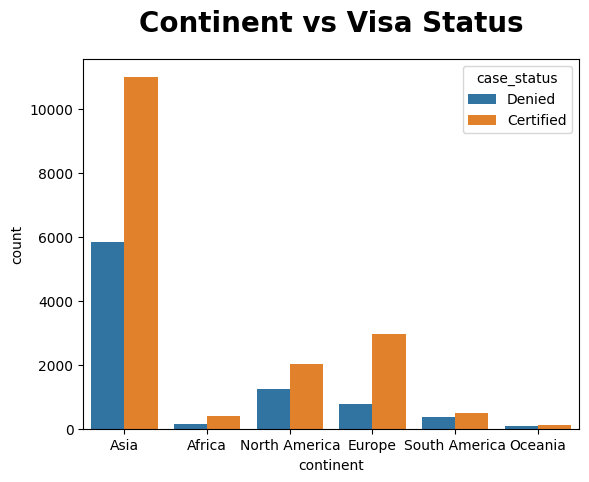

In [54]:
sns.countplot(x='continent',data=df,hue='case_status')
plt.title("Continent vs Visa Status", weight="bold",fontsize=20, pad=20)
plt.show()

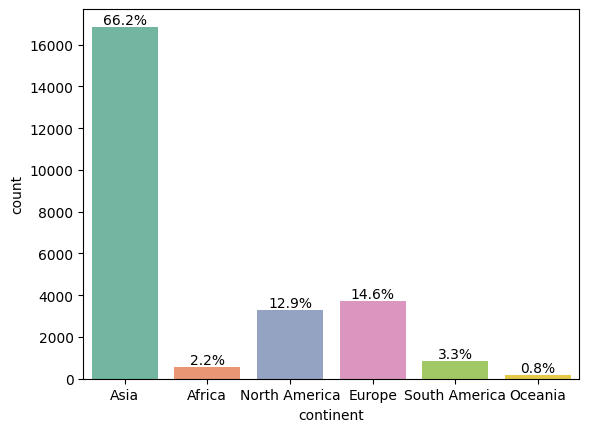

In [49]:
ax = sns.countplot(x='continent', data=df, palette='Set2')
total = len(df)
for c in ax.containers:
    ax.bar_label(c, labels=[f'{v/total*100:.1f}%' for v in c.datavalues])

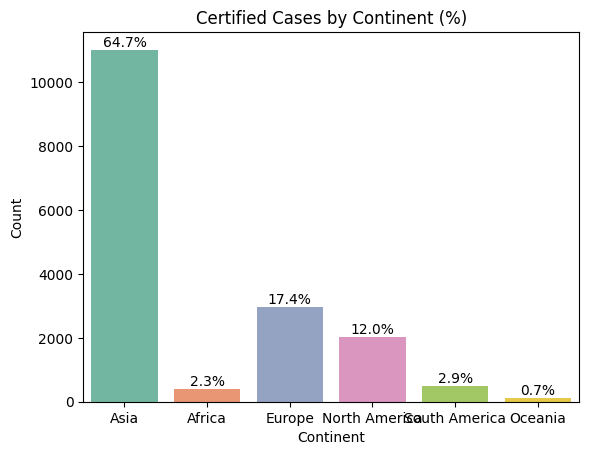

In [53]:
# Filter Certified cases
df_certified = df[df['case_status'] == 'Certified']

# Plot
ax = sns.countplot(x='continent', data=df_certified, palette='Set2')

# Percentages
total_cert = len(df_certified)
for c in ax.containers:
    ax.bar_label(c, labels=[f'{v/total_cert*100:.1f}%' for v in c.datavalues])

plt.title('Certified Cases by Continent (%)')
plt.xlabel('Continent')
plt.ylabel('Count')
plt.show()